In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [ ]:
from src.data_loader import VesselDataLoader
from src.visualizer import VesselVisualizer
from src.mission_profiler import MissionProfiler

In [ ]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
loader = VesselDataLoader(raw_data_file2)

# Load and clean the data
df = loader.load_and_clean()

profiler = MissionProfiler(df, speed_threshold=1.0)
df_profiled = profiler.classify_phases()


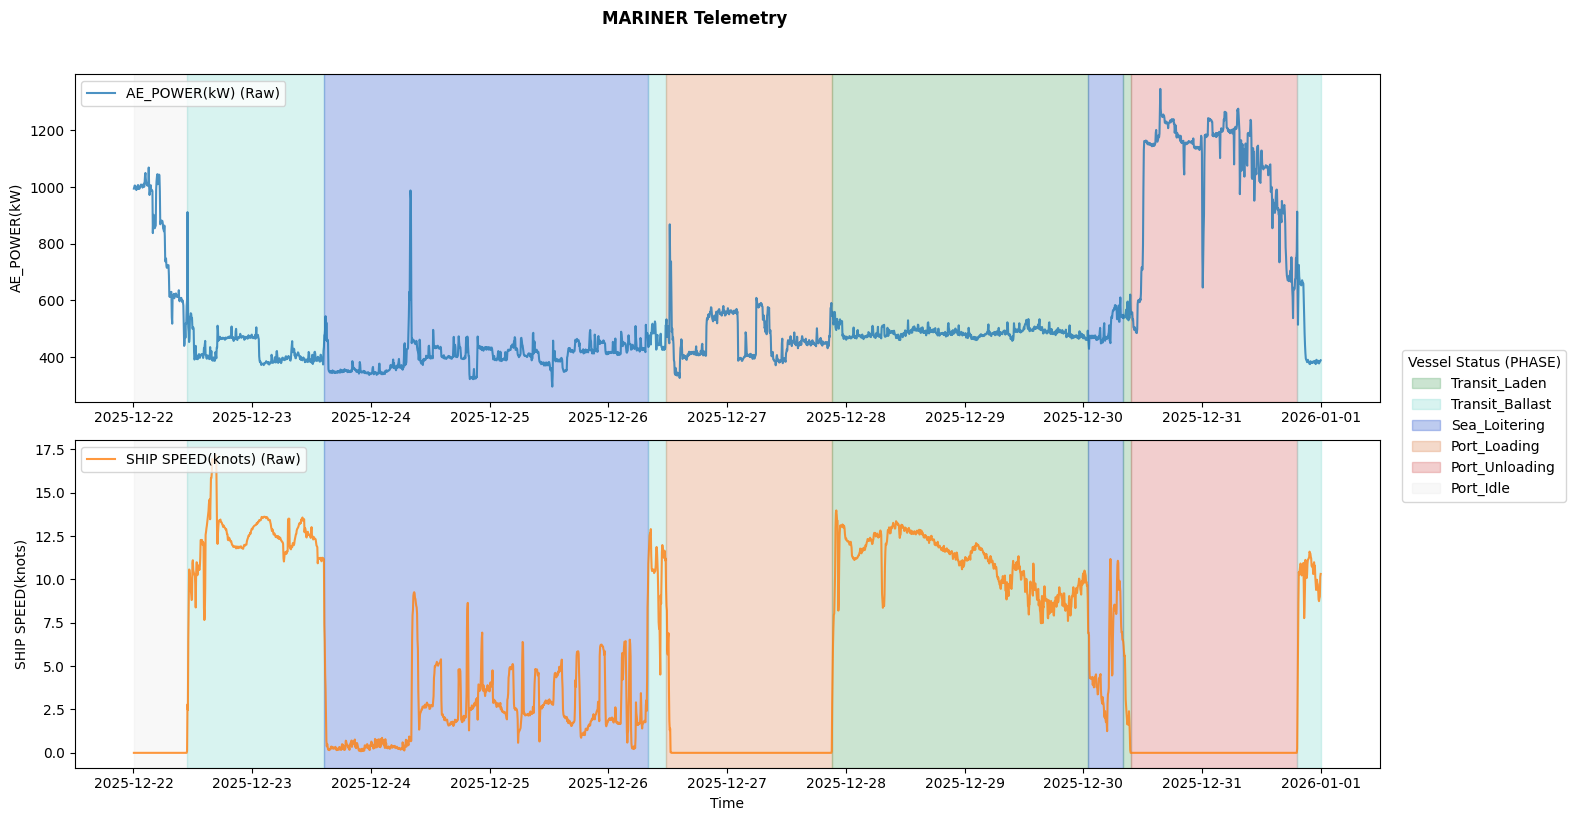

In [ ]:
plotter = VesselVisualizer(df_profiled)

# Plot using the original STATUS column
fig, ax = plotter.plot_series(columns=['AE_POWER(kW)', 'SHIP SPEED(knots)'],subplots=True, status_col='PHASE')

In [ ]:
vessel_map = plotter.plot_trajectory_folium(status_col='PHASE')
vessel_map

In [ ]:
plotter2 = VesselVisualizer(df2)

# Plot using the original STATUS column
fig, ax = plotter2.plot_series(columns=['AE_POWER(kW)', 'SHIP SPEED(knots)'],subplots=True, status_col='STATUS')

NameError: name 'df2' is not defined

In [ ]:
vessel_map2 = plotter2.plot_trajectory_folium(status_col='STATUS')
vessel_map2